# Handling Categorical Missing Data

- most-frequent
- Filling values at random

## Assumptions for Categorical data

- Data missing completely at random (MCAR)
- Implementing most-frequent technique based on mode is easier to implement.
- we also use "missing" word to fill missing data

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/housing-dataset/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [3]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [4]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of houses')

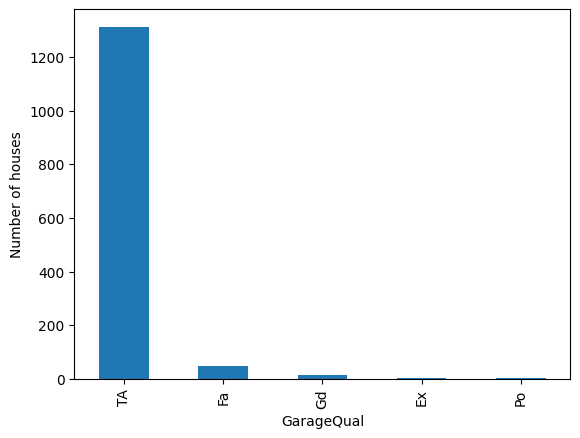

In [5]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [6]:
df['GarageQual'].fillna('Missing')
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
139,NaN,TA,231500
802,Gd,TA,189000
1137,NaN,NaN,94000
654,TA,TA,350000
1154,Gd,TA,201800


In [7]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [8]:
print(df.head())

  FireplaceQu GarageQual  SalePrice
0         NaN         TA     208500
1          TA         TA     181500
2          TA         TA     223500
3          Gd         TA     140000
4          TA         TA     250000


In [9]:
print(df.columns.tolist())

['FireplaceQu', 'GarageQual', 'SalePrice']


In [10]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

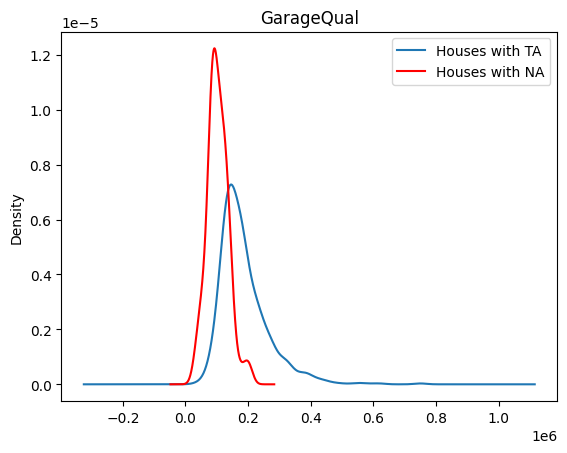

In [11]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Houses with TA','Houses with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

Lets replace missing values by mode

In [12]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [13]:
df['GarageQual'].fillna('TA')

0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: object

<Axes: xlabel='GarageQual'>

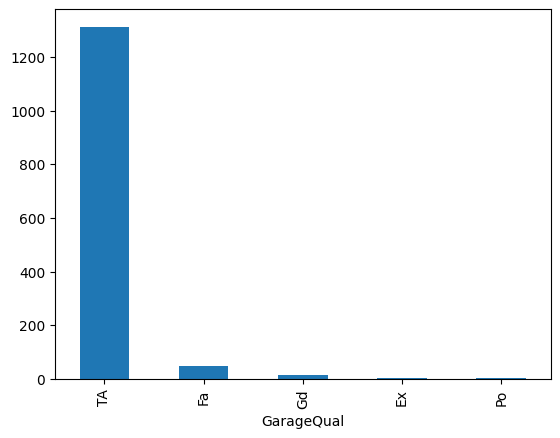

In [14]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

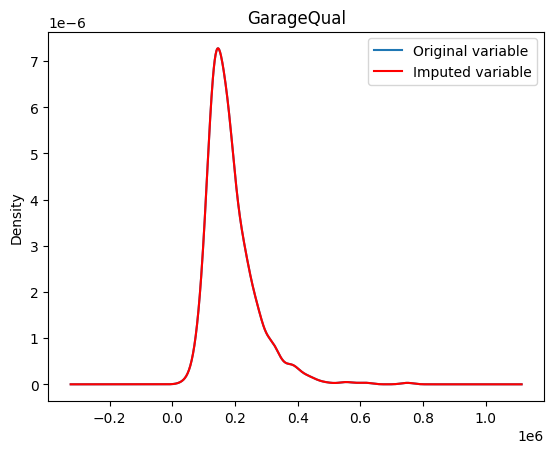

In [15]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original variable','Imputed variable']
ax.legend(lines,labels,loc='best')

# add title
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

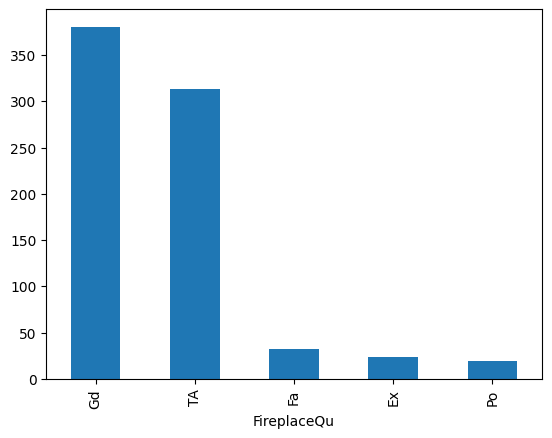

In [16]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'fireplaceQu')

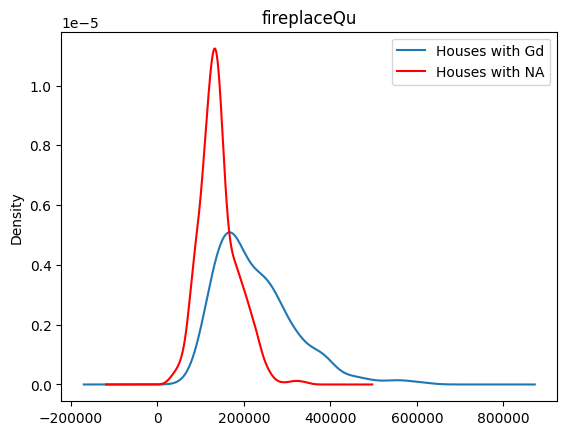

In [17]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Houses with Gd','Houses with NA']
ax.legend(lines,labels,loc='best')

plt.title('fireplaceQu')

In [18]:
df['FireplaceQu'].fillna('Gd')

0       Gd
1       TA
2       TA
3       Gd
4       TA
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    Gd
Name: FireplaceQu, Length: 1460, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

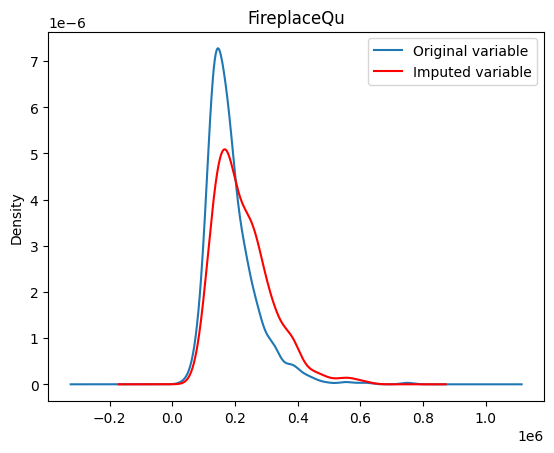

In [19]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original variable','Imputed variable']

ax.legend(lines,labels,loc='best')

# add title
plt.title('FireplaceQu')

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)


In [21]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [22]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# Missing Category Imputation

In [23]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/housing-dataset/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [24]:
df['GarageQual'].fillna('Missing')

0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: object

Text(0, 0.5, 'Number of houses')

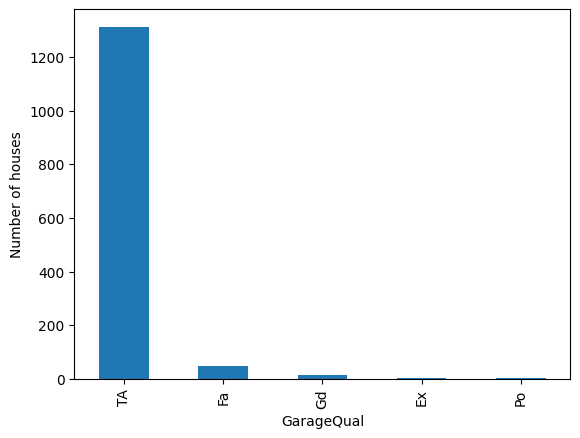

In [25]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)


In [27]:
from sklearn.impute import SimpleImputer

In [28]:
imputer=SimpleImputer(strategy='constant',fill_value='Missing')

In [29]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [30]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)